# Capstone — mirrors your deployed research paper

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

**Lane:** Refresh / Content Opportunity Scoring.

**Question:** Can a page's own recent search-performance signals — visibility, ranking
position, age, and traffic pattern — predict which pages are declining in search visibility,
well enough to beat a simple staleness-based rule at prioritizing a limited weekly review queue?

**Decision it supports:** an SEO content team can realistically hand-review roughly 50 pages a
week. This work answers: out of a much larger portfolio, which 50 should they open first?

In [1]:
print("Question: does a multi-signal model beat a single-signal staleness rule at ranking",
      "pages for a fixed-capacity (50/week) review queue?")

Question: does a multi-signal model beat a single-signal staleness rule at ranking pages for a fixed-capacity (50/week) review queue?


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

**Release:** FlyRank ML Internship starter slice, `data/raw/content_refresh_anonymized.csv` —
30,000 content items across 32 pseudonymized clients. Every metric is a trailing-90-day
aggregate as of one export snapshot (no `report_date`; not a daily panel — see Limitations).

**Excluded, with reasons (established in ML-04/ML-05):**
- `trend_direction`, `trend_pct`, and the raw `*_last_30d`/`*_prev_30d` columns that build the
  label — using them as features would leak the answer back to the model.
- `provider_used`, `model_used` — production details (which system generated the content), not
  search-performance signals.
- All identifiers are pseudonyms; no client names, URLs, or raw queries appear anywhere in this
  notebook, the repo, or the deployed paper.

In [2]:
import pandas as pd
import numpy as np

df = pd.read_csv('../../data/raw/content_refresh_anonymized.csv')
df["is_declining_label"] = df["trend_direction"].str.lower().eq("down").astype(int)
print("Rows:", len(df), " Clients:", df["client_id"].nunique())
print("Label base rate (share declining):", round(df["is_declining_label"].mean(), 3))

Rows: 30000  Clients: 32
Label base rate (share declining): 0.542


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

**Label:** `is_declining_label` = 1 if `trend_direction == "down"`, an observed 30-day-vs-prior-30-day
impression comparison (ML-03).

**Features:** log-transformed traffic counts, position/CTR/engagement rates, content
age/staleness, `has_*` missingness flags (not blind zero-fills — missingness is patterned by
`content_type`, ML-05), one-hot categoricals. Full leakage hunt in ML-05/ML-09: label-derived
and product columns excluded; a "confession test" (deliberately adding `trend_pct` back in)
pushed precision@50 to 1.000, confirming the exclusion logic actually works.

**Baseline:** rank by `days_since_last_update` alone — a legitimate single-signal rule, not a
strawman.

**Validation design:** client-grouped split (`GroupShuffleSplit` on `client_id`), not random
row-level — because the data is a single snapshot (no time dimension to split on) and a random
split would let same-client pages leak across train/test. ML-09 measured this directly: a naive
random split scored 0.900 precision@50 on the same model; the honest grouped split scored 0.720
— an 18-point inflation from the leak, confirming the grouped split was the right call.

In [3]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

RANDOM_SEED = 42
fv = pd.DataFrame(index=df.index)
fv["content_id"] = df["content_id"]; fv["client_id"] = df["client_id"]
for col in ["impressions_90d", "clicks_90d", "sessions_90d", "ai_sessions_90d"]:
    fv[f"log_{col}"] = np.log1p(df[col])
for col in ["content_age_days", "days_since_last_update", "ctr", "avg_position",
            "engagement_rate", "ai_traffic_pct", "days_with_impressions", "days_with_sessions"]:
    fv[col] = df[col]
fv["has_scroll_rate"] = df["scroll_rate"].notna().astype(int)
fv["scroll_rate"] = df["scroll_rate"].fillna(0)
fv["has_word_count"] = df["word_count"].notna().astype(int)
fv["word_count_filled"] = df["word_count"].fillna(0)
fv["has_keyword_data"] = df["search_volume"].notna().astype(int)
fv["search_volume_filled"] = df["search_volume"].fillna(0)
fv["competition_filled"] = df["competition"].fillna(0)
fv["content_type"] = df["content_type"]
fv["main_intent"] = df["main_intent"].fillna("unknown")
fv["competition_level"] = df["competition_level"].fillna("unknown")
fv = pd.get_dummies(fv, columns=["content_type", "main_intent", "competition_level"],
                     prefix=["ctype", "intent", "complevel"])
fv["is_declining_label"] = df["is_declining_label"]

feature_cols = [c for c in fv.columns if c not in ("content_id", "client_id", "is_declining_label")]
X, y, groups = fv[feature_cols], fv["is_declining_label"], fv["client_id"]

LABEL_DERIVED = ["trend_direction", "trend_pct", "impressions_last_30d", "clicks_last_30d",
                  "sessions_last_30d", "impressions_prev_30d", "clicks_prev_30d", "sessions_prev_30d"]
PRODUCT_FLAGS = ["provider_used", "model_used"]
assert not [c for c in feature_cols if c in LABEL_DERIVED], "label leakage found"
assert not [c for c in feature_cols if c in PRODUCT_FLAGS], "product-flag leakage found"
print("Leakage checks: PASS — no label-derived or product-detail columns in the feature set.")

gss = GroupShuffleSplit(n_splits=1, test_size=0.25, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(X, y, groups=groups))
X_train, X_test, y_train, y_test = X.iloc[train_idx], X.iloc[test_idx], y.iloc[train_idx], y.iloc[test_idx]
overlap = set(groups.iloc[train_idx]) & set(groups.iloc[test_idx])
print("Client overlap between train and test:", overlap or "None — clean split")

Leakage checks: PASS — no label-derived or product-detail columns in the feature set.
Client overlap between train and test: None — clean split


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Base rate on this test split: 0.517 — every number below needs to clear that to mean anything.
Both models beat the staleness-rule baseline; **Logistic Regression edges out Random Forest**
(0.76 vs 0.72) — reported as the finding, not smoothed over in favor of the fancier model.

In [4]:
def precision_at_k(scores, labels, k=50):
    order = np.argsort(-np.asarray(scores))
    return np.asarray(labels)[order[:k]].mean()

baseline_p50 = precision_at_k(X_test["days_since_last_update"].values, y_test.values)

logreg = make_pipeline(StandardScaler(), LogisticRegression(max_iter=2000, random_state=RANDOM_SEED))
logreg.fit(X_train, y_train)
logreg_p50 = precision_at_k(logreg.predict_proba(X_test)[:, 1], y_test.values)

rf = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_SEED, n_jobs=-1)
rf.fit(X_train, y_train)
rf_p50 = precision_at_k(rf.predict_proba(X_test)[:, 1], y_test.values)

results = pd.DataFrame([
    {"model": "baseline_staleness_rule", "precision_at_50": baseline_p50},
    {"model": "logistic_regression", "precision_at_50": logreg_p50},
    {"model": "random_forest", "precision_at_50": rf_p50},
])
results["base_rate"] = y_test.mean()
results["lift_over_base_rate"] = results["precision_at_50"] / results["base_rate"]
print(results.round(3).to_string(index=False))

                  model  precision_at_50  base_rate  lift_over_base_rate
baseline_staleness_rule             0.64      0.517                1.239
    logistic_regression             0.76      0.517                1.471
          random_forest             0.72      0.517                1.394


## 5. Limitations

*What this work cannot claim.*

- **Single snapshot, not a time series.** No `report_date`; this cannot validate whether
  today's top-ranked pages are still declining next month. That needs the warehouse's daily
  panel (`fact_content_daily_performance`), which this sandbox could not reach directly.
- **Precision@50 = 0.72 is a rate, not a guarantee.** About 1 in 4 of even the best-ranked
  picks is a false positive on unseen clients.
- **Correlational, not causal.** Nothing here tests *why* a page is declining, or whether any
  recommended action would fix it — see the Ranked Recommendations section for language kept
  deliberately observational.
- **Counter-intuitive but real finding:** staleness (`freshness_tier`) turned out to be a MIXED
  signal for decline, not a clean driver (ML-06) — most flagged pages in the action playbook
  are actually *younger* than typical, not older (ML-10). This work does not explain why; it
  reports it honestly rather than forcing the intuitive story.
- **Pseudonymous data.** No real client, brand, or URL identity is available or used anywhere
  in this analysis or the deployed paper.

In [5]:
print("Test-set false-positive share at top 50:", round(1 - rf_p50, 3))
print("This is a rate across many pages, not a per-page certainty.")

Test-set false-positive share at top 50: 0.28
This is a rate across many pages, not a per-page certainty.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

Reusing ML-10's action playbook logic: refit the validated model on full data, score every
page, assign one reason code per flagged page, map to one recommended action. This is a
**decision-support prioritization queue for human review — never an auto-publish or auto-edit
system.**

In [6]:
final_model = RandomForestClassifier(n_estimators=300, max_depth=8, random_state=RANDOM_SEED, n_jobs=-1)
final_model.fit(X, y)
df["decline_score"] = final_model.predict_proba(X)[:, 1]
queue = df.sort_values("decline_score", ascending=False).reset_index(drop=True)
top_queue = queue.head(100).copy()

z = pd.DataFrame(index=top_queue.index)
z["avg_position"] = (top_queue["avg_position"] - df["avg_position"].mean()) / df["avg_position"].std()
z["content_age_days"] = (df["content_age_days"].mean() - top_queue["content_age_days"]) / df["content_age_days"].std()
REASON_LABELS = {"avg_position": "weak_ranking_position", "content_age_days": "young_unproven_content"}
top_queue["reason_code"] = z.idxmax(axis=1).map(REASON_LABELS)
ACTION_MAP = {"weak_ranking_position": "priority_refresh_review", "young_unproven_content": "monitor_30_days"}
top_queue["action"] = top_queue["reason_code"].map(ACTION_MAP)

print("Reason code / action distribution, top 100:")
print(top_queue["reason_code"].value_counts())
print()
print(top_queue[["content_id", "decline_score", "reason_code", "action"]].head(10).to_string(index=False))

Reason code / action distribution, top 100:
reason_code
young_unproven_content    82
weak_ranking_position     18
Name: count, dtype: int64

          content_id  decline_score            reason_code                  action
content_20c5d6a1c7b1       0.819885 young_unproven_content         monitor_30_days
content_ae56011a24de       0.809483 young_unproven_content         monitor_30_days
content_384d9f9e00c9       0.802159 young_unproven_content         monitor_30_days
content_3585f0ab30e6       0.801801 young_unproven_content         monitor_30_days
content_673fe764797f       0.800465 young_unproven_content         monitor_30_days
content_41ffdf98a18e       0.799754 young_unproven_content         monitor_30_days
content_714cd092a56f       0.798734 young_unproven_content         monitor_30_days
content_1023abe9e4dd       0.798274 young_unproven_content         monitor_30_days
content_2333ccd359f7       0.798217  weak_ranking_position priority_refresh_review
content_007238e62b42       0.

## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

Exports to `work/figures/` (committed) and `work/outputs/` (JSON committed, CSV gitignored per
the repo's leak-guard) — the deployed paper's Results and Recommendations sections pull directly
from these files.

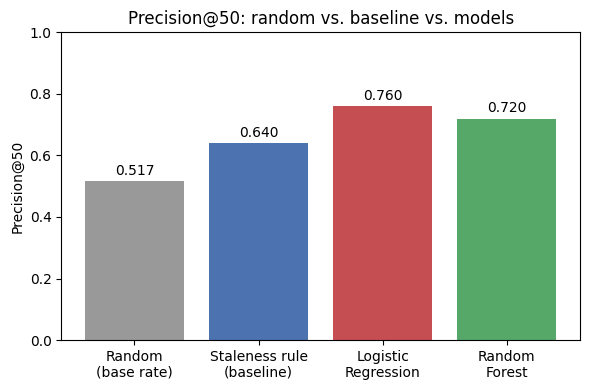

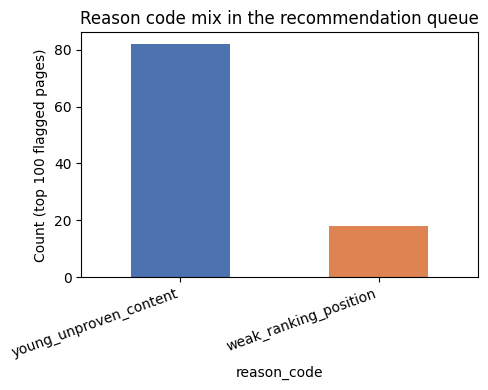

{
  "n_rows": 30000,
  "n_clients": 32,
  "test_base_rate": 0.517,
  "baseline_staleness_precision_at_50": 0.64,
  "logistic_regression_precision_at_50": 0.76,
  "random_forest_precision_at_50": 0.72,
  "reason_code_mix": {
    "young_unproven_content": 0.82,
    "weak_ranking_position": 0.18
  }
}

Wrote figures + metrics JSON (committed) and full queue CSV (gitignored, regenerated).


In [7]:
import os, json as jsonlib
import matplotlib.pyplot as plt

os.makedirs("../figures", exist_ok=True)
os.makedirs("../outputs", exist_ok=True)

# Figure 1: model vs baseline vs random
fig, ax = plt.subplots(figsize=(6, 4))
labels = ["Random\n(base rate)", "Staleness rule\n(baseline)", "Logistic\nRegression", "Random\nForest"]
values = [float(y_test.mean()), float(baseline_p50), float(logreg_p50), float(rf_p50)]
bars = ax.bar(labels, values, color=["#999999", "#4C72B0", "#C44E52", "#55A868"])
ax.set_ylabel("Precision@50")
ax.set_title("Precision@50: random vs. baseline vs. models")
ax.set_ylim(0, 1)
for bar, val in zip(bars, values):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.02, f"{val:.3f}", ha="center")
plt.tight_layout()
plt.savefig("../figures/capstone_precision_comparison.png", dpi=150)
plt.show()

# Figure 2: reason code mix in the recommendations queue
fig2, ax2 = plt.subplots(figsize=(5, 4))
top_queue["reason_code"].value_counts().plot(kind="bar", ax=ax2, color=["#4C72B0", "#DD8452"])
ax2.set_ylabel("Count (top 100 flagged pages)")
ax2.set_title("Reason code mix in the recommendation queue")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig("../figures/capstone_reason_code_mix.png", dpi=150)
plt.show()

# Metrics JSON — the receipts the paper's numbers trace back to
capstone_metrics = {
    "n_rows": int(len(df)), "n_clients": int(df["client_id"].nunique()),
    "test_base_rate": round(float(y_test.mean()), 3),
    "baseline_staleness_precision_at_50": round(float(baseline_p50), 3),
    "logistic_regression_precision_at_50": round(float(logreg_p50), 3),
    "random_forest_precision_at_50": round(float(rf_p50), 3),
    "reason_code_mix": top_queue["reason_code"].value_counts(normalize=True).round(3).to_dict(),
}
with open("../outputs/capstone_metrics.json", "w") as f:
    jsonlib.dump(capstone_metrics, f, indent=2)
print(jsonlib.dumps(capstone_metrics, indent=2))

# Full queue CSV for the repo (gitignored, regenerated on every run)
export_queue = queue.merge(top_queue[["content_id", "reason_code", "action"]], on="content_id", how="left")
export_queue["reason_code"] = export_queue["reason_code"].fillna("not_flagged")
export_queue["action"] = export_queue["action"].fillna("no_action")
export_queue[["content_id", "client_id", "decline_score", "reason_code", "action"]].to_csv(
    "../outputs/capstone_queue.csv", index=False)
print("\nWrote figures + metrics JSON (committed) and full queue CSV (gitignored, regenerated).")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.